# Wine Quality Prediction


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# load dataset
data=pd.read_csv("Wine quality.csv")
data.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
863,10.9,0.320,0.52,1.8,0.132,17.0,44.0,0.99734,3.28,0.77,11.5,6,1221
1033,6.6,0.580,0.02,2.0,0.062,37.0,53.0,0.99374,3.35,0.76,11.6,7,1452
1111,6.9,0.630,0.33,6.7,0.235,66.0,115.0,0.99787,3.22,0.56,9.5,5,1558
449,10.1,0.935,0.22,3.4,0.105,11.0,86.0,1.00100,3.43,0.64,11.3,4,633
581,7.4,0.530,0.12,1.9,0.165,4.0,12.0,0.99702,3.26,0.86,9.2,5,808


In [ ]:
print("shape of data:",data.shape)
print(data.info())
print(data.describe())

shape of data: (1143, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None
       fixed acidity  volatile acidity  citr

In [ ]:
data.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
data=data.drop_duplicates()

In [ ]:
#  drop 'Id' is just a row identifier
data=data.drop(columns=["Id"])

In [ ]:
data['quality'].unique()

array([5, 6, 7, 4, 8, 3])

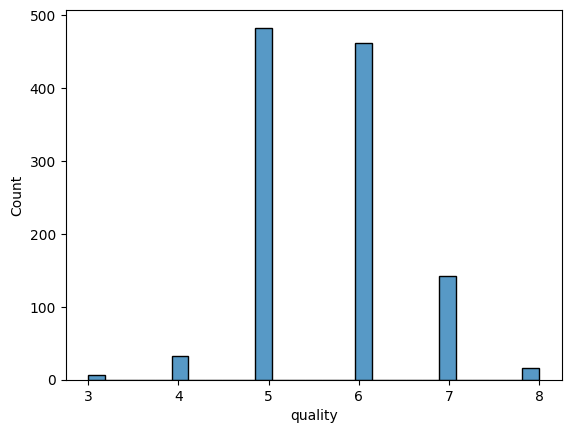

In [ ]:
sns.histplot(data,x="quality")
plt.show()

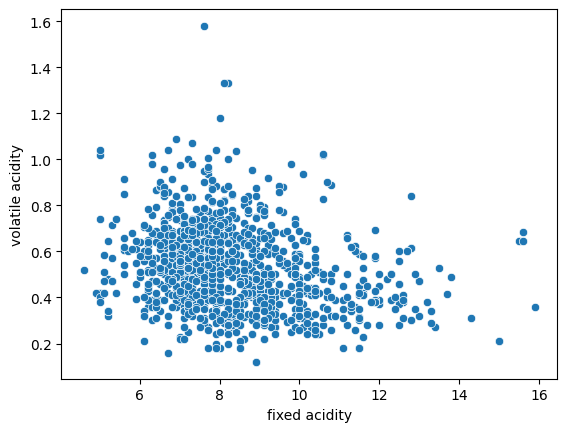

In [ ]:
# fixed acidity vs volatile acidity
sns.scatterplot(data,x="fixed acidity",y="volatile acidity")
plt.show()

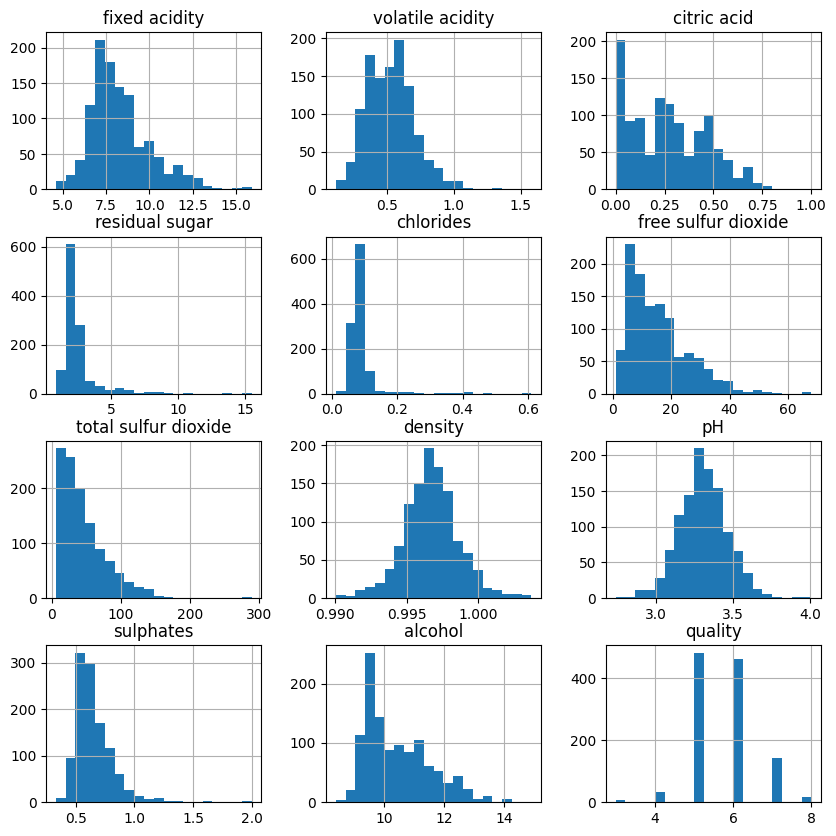

In [ ]:
data.hist(bins=20,figsize=(10,10))
plt.show()

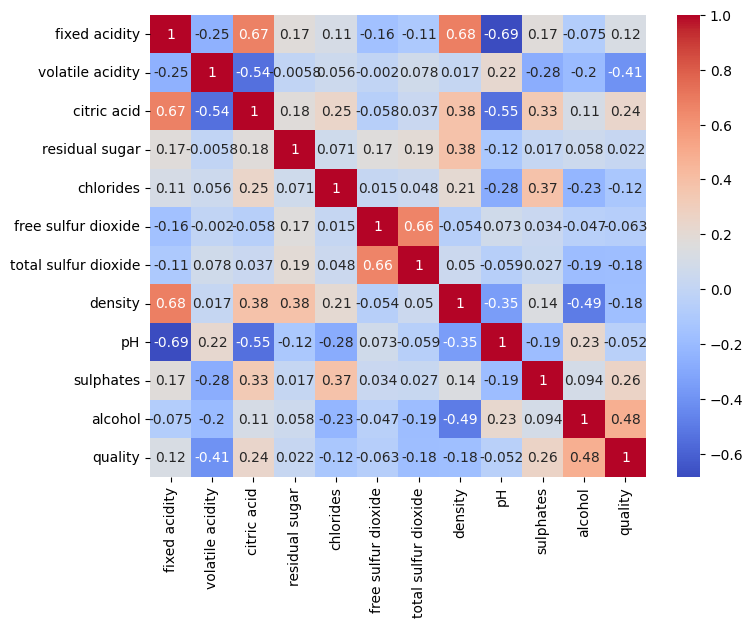

In [ ]:
# correation heatmap
corr=data.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

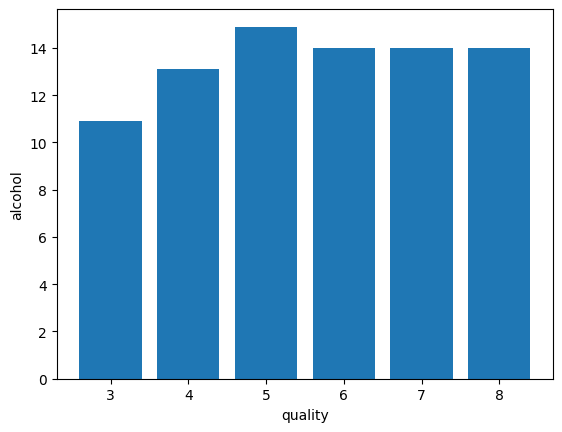

In [ ]:
plt.bar(data["quality"],data["alcohol"])
plt.xlabel("quality")
plt.ylabel("alcohol")
plt.show()

quality_binary
good    621
bad     522
Name: count, dtype: int64
quality_3class
medium    945
high      159
low        39
Name: count, dtype: int64


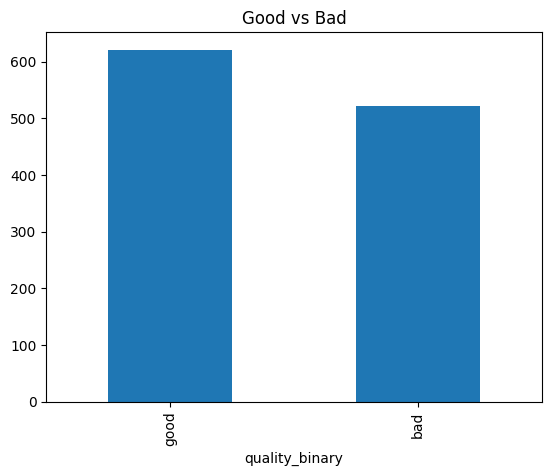

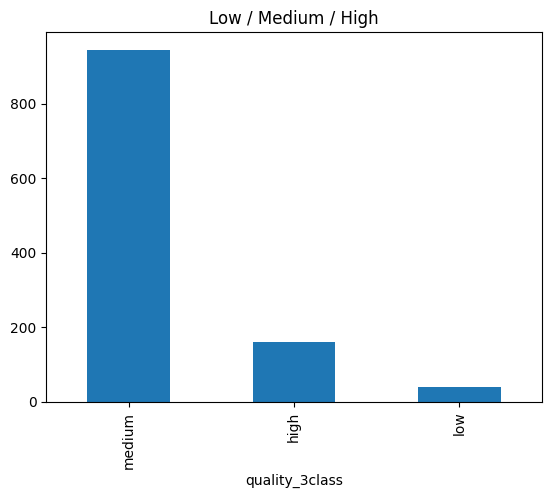

In [ ]:
def get_binary(score):
    if score >= 6:
        return "good"
    else:
        return "bad"
def get_3class(score):
    if score <= 4:
        return "low"
    elif score <= 6:
        return "medium"
    else:
        return "high"

# to create our new columns
data['quality_binary'] = data['quality'].apply(get_binary)
data['quality_3class'] = data['quality'].apply(get_3class)
print(data['quality_binary'].value_counts())
print(data['quality_3class'].value_counts())

# plot
data['quality_binary'].value_counts().plot(kind='bar', title='Good vs Bad')
plt.show()

# Plot the 3-Class column
data['quality_3class'].value_counts().plot(kind='bar', title='Low / Medium / High')
plt.show()

# Train/test split

In [ ]:
X=data.drop(["quality","quality_binary","quality_3class"],axis=1)
y=data["quality_binary"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# model training

# Random Forest Classified

In [ ]:
rfc = RandomForestClassifier(n_estimators=200,class_weight="balanced")
rfc.fit(X_train, y_train)
pred_rf= rfc.predict(X_test)

In [ ]:
print(f"Accuracy Score: {accuracy_score(y_test, pred_rf):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred_rf))

Accuracy Score: 0.8122

Classification Report:
              precision    recall  f1-score   support

         bad       0.82      0.75      0.79       105
        good       0.80      0.86      0.83       124

    accuracy                           0.81       229
   macro avg       0.81      0.81      0.81       229
weighted avg       0.81      0.81      0.81       229

Confusion Matrix:
[[ 79  26]
 [ 17 107]]


# SGD

In [ ]:
sgd = SGDClassifier(penalty=None,class_weight="balanced")
sgd.fit(X_train_scaled, y_train)
pred_sgd = sgd.predict(X_test_scaled)

In [ ]:
print(f"Accuracy Score: {accuracy_score(y_test, pred_sgd):.4f}\n")
print(classification_report(y_test,pred_sgd))
print(confusion_matrix(y_test,pred_sgd))

Accuracy Score: 0.7555

              precision    recall  f1-score   support

         bad       0.73      0.73      0.73       105
        good       0.77      0.77      0.77       124

    accuracy                           0.76       229
   macro avg       0.75      0.75      0.75       229
weighted avg       0.76      0.76      0.76       229

[[77 28]
 [28 96]]


# Support Vector Classifier

In [ ]:
svc = SVC(class_weight="balanced")
svc.fit(X_train_scaled, y_train)
pred_svc = svc.predict(X_test_scaled)

In [ ]:
print(f"Accuracy Score: {accuracy_score(y_test, pred_svc):.4f}\n")
print(classification_report(y_test, pred_svc))
print(confusion_matrix(y_test,pred_svc))

Accuracy Score: 0.7729

              precision    recall  f1-score   support

         bad       0.74      0.77      0.76       105
        good       0.80      0.77      0.79       124

    accuracy                           0.77       229
   macro avg       0.77      0.77      0.77       229
weighted avg       0.77      0.77      0.77       229

[[81 24]
 [28 96]]


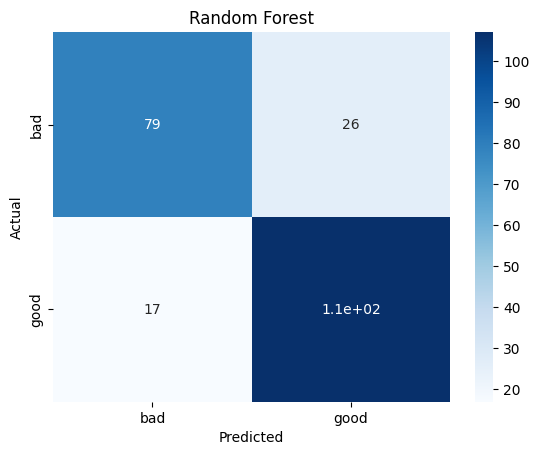

In [ ]:
sns.heatmap(confusion_matrix(y_test, pred_rf), annot=True, cmap='Blues',
                xticklabels=['bad', 'good'], yticklabels=['bad', 'good'])

plt.title("Random Forest")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

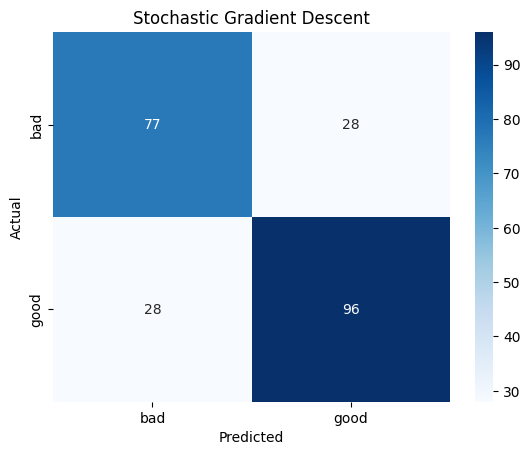

In [ ]:
sns.heatmap(confusion_matrix(y_test, pred_sgd), annot=True, cmap='Blues',
                xticklabels=['bad', 'good'], yticklabels=['bad', 'good'])

plt.title("Stochastic Gradient Descent")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

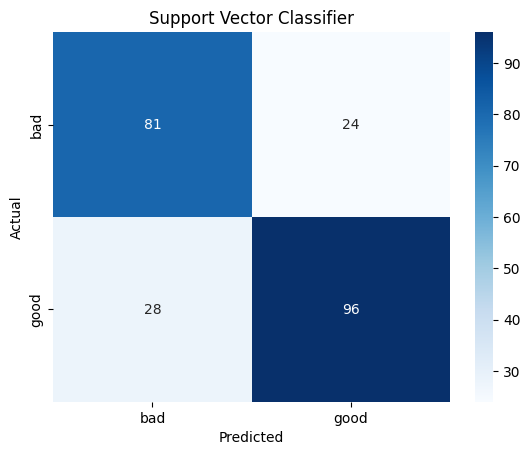

In [ ]:
sns.heatmap(confusion_matrix(y_test, pred_svc), annot=True, cmap='Blues',
                xticklabels=['bad', 'good'], yticklabels=['bad', 'good'])

plt.title("Support Vector Classifier")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# feature importance

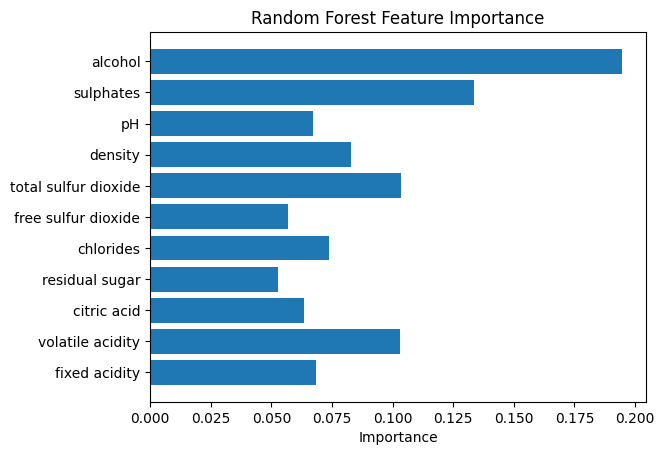

In [ ]:
plt.barh(X.columns, rfc.feature_importances_)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.show()

`alcohol` and `sulphates` are the top two predictors,
followed by `volatile acidity` and `total sulfur dioxide` - broadly
consistent with the correlation analysis

# comparision table

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {"Random Forest": pred_rf, "SGD": pred_sgd, "SVC": pred_svc}

rows = []
for name, pred in models.items():
    rows.append([
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, pos_label="good"),
        recall_score(y_test, pred, pos_label="good"),
        f1_score(y_test, pred, pos_label="good")
    ])

comparison = pd.DataFrame(rows, index=models.keys(),
                           columns=["Accuracy", "Precision", "Recall", "F1 Score"]).round(4)
comparison

,Accuracy,Precision,Recall,F1 Score
Random Forest,0.8122,0.8045,0.8629,0.8327
SGD,0.7555,0.7742,0.7742,0.7742
SVC,0.7729,0.8000,0.7742,0.7869


# Conclusion

This project classified wine quality as "good" or "bad" using physicochemical features. Among the three models tested, Random Forest performed best with 81% accuracy and the highest F1 score (0.83), followed by SVC (77%) and SGD (76%).

Alcohol and sulphates emerged as the strongest predictors of quality, consistent with the correlation analysis — higher alcohol and sulphate levels are associated with better-rated wines.